----Beginning empirical evaluation across scales...
-> Benchmark testing size: 10 nodes
-> Benchmark testing size: 20 nodes
-> Benchmark testing size: 30 nodes
-> Benchmark testing size: 40 nodes
-> Benchmark testing size: 50 nodes

 METRIC SUMMARY MATRIX
 Problem_Scale HC_Avg_Dist HC_Std_Dist HC_Avg_Time GA_Avg_Dist GA_Std_Dist GA_Avg_Time
            10      290.31        0.00      0.0009      290.31        0.00      1.4200
            20      386.49        0.09      0.0144      401.27       25.63      1.5827
            30      467.97       15.39      0.0758      496.48       17.55      1.9489
            40      518.17       23.64      0.2509      591.12       40.83      2.3715
            50      589.07       13.22      0.7464      707.55       23.03      2.8188
----Beginning empirical evaluation across scales...
-> Benchmark testing size: 10 nodes
-> Benchmark testing size: 20 nodes
-> Benchmark testing size: 30 nodes
-> Benchmark testing size: 40 nodes
-> Benchmark testing size:

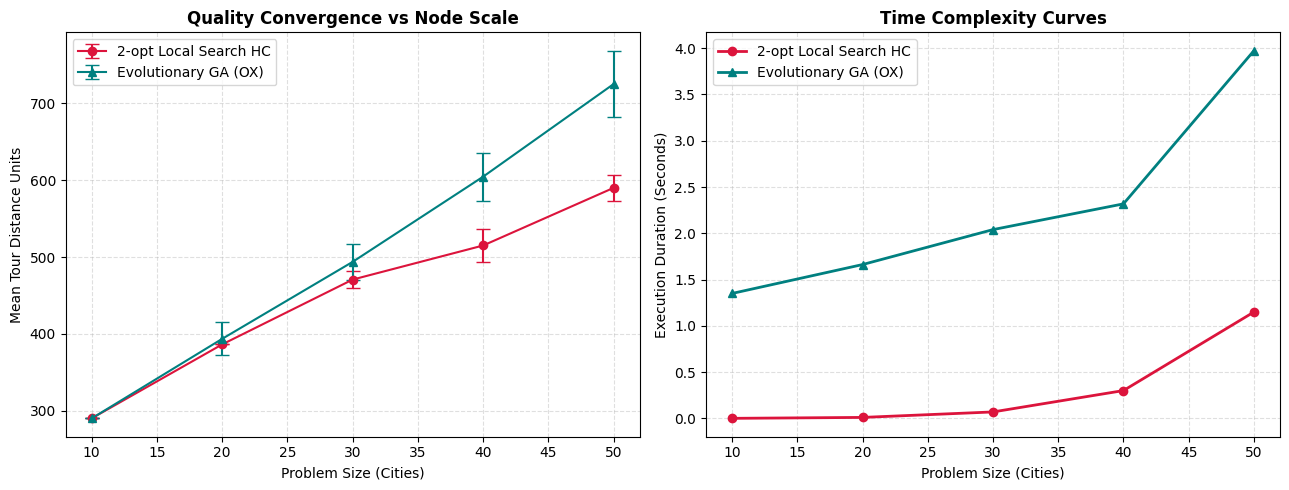

In [12]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


class CityDataset:
    """Handles reading the CSV file and setting up our TSP Metrics."""


    # Change __init_ to __init__
    def __init__(self, csv_path):
        self.data = pd.read_csv(csv_path)
        self.coordinates = self.data[['X', 'Y']].values
        self.total_cities = len(self.coordinates)

    def load_subinstance(self, size):
        """ Extract a subset of cities(10,20,30,50) for scaling tests."""
        sub_coords = self.coordinates[:size]


        #build distance lookup table using euclidean formula
        dis_matrix = np.zeros((size, size))
        for i in range(size):
            for j in range(size):
                dis_matrix[i][j] = np.linalg.norm(sub_coords[i] - sub_coords[j])
        return dis_matrix
    
    @staticmethod
    def get_tour_distance(route, dist_matrix):
        """ Sums up the round trip distance for the current rout sequence."""

        total_dist = 0
        n = len(route)
        for i in range(n):
            total_dist += dist_matrix[route[i],route[(i +1) % n]]
        return total_dist
    
class TspSolvers:
    """Contains our implimentations for local search and evolutionary GA."""

    @staticmethod
    def local_search_2opt(n_cities, d_matrix, data_manager):
        t_start = time.time()


        best_tour = list(np.random.permutation(n_cities))
        best_val = data_manager.get_tour_distance(best_tour, d_matrix)

        keep_searching = True
        while keep_searching:
            keep_searching = False
            for i in range(n_cities - 1):
                for j in range(i +1, n_cities):
                    
                    # tweek the route using a 2_opt edge in versation
                    test_tour = best_tour.copy()
                    test_tour[i:j + 1] = list(reversed(test_tour[i:j + 1]))
                    test_val = data_manager.get_tour_distance(test_tour, d_matrix)


                    if test_val < best_val:
                        best_tour = test_tour
                        best_val = test_val
                        keep_searching = True
                        break
                if keep_searching:
                   break
        elapsed = time.time() - t_start
        return best_val, elapsed 
    @staticmethod

    def genetic_algorithm(n_cities, d_matrix, data_manager, pop_size=50, gens=300, mut_rate=0.08):
        t_start = time.time()

        #Internal GA Genwtic operators
        def run_ox_crossover(parent_a, parent_b):
            """ mutation crosover keeping order intact without duplicate"""
            pt1,pt2 = sorted(np.random.choice(range(n_cities), 2, replace=False))
            offspring = [-1] * n_cities
            offspring[pt1:pt2 + 1] = parent_a[pt1:pt2 + 1]

            remainder = [item for item in parent_b if item not in offspring]
            r_idx = 0
            for i in range(n_cities):
                if offspring[i] == -1:
                    offspring[i] = remainder[r_idx]
                    r_idx += 1
            return offspring

        # Intyernal Ga Genetic Operators ======       
        def run_inversion_mutation(tour):
            """flip the random chunk of the path sequence"""

            pt1,pt2 = sorted(np.random.choice(range(n_cities), 2, replace=False))
            tour[pt1:pt2 + 1] = list(reversed(tour[pt1:pt2 + 1]))
            return tour
        
        # setup random generation
        pop = [list(np.random.permutation(n_cities)) for _ in range(pop_size)]
        top_overall_score = float('inf')
        top_overall_rout = None

        for g in range(gens):
            fitness_scores = [data_manager.get_tour_distance(ind, d_matrix) for ind in pop]
            best_idx = np.argmin(fitness_scores)


            if fitness_scores[best_idx] < top_overall_score:
                top_overall_score = fitness_scores[best_idx]
                top_overall_rout = pop[best_idx].copy()


            #replacement next gneration using 5-players tounament slection and crosover

            next_generation = [top_overall_rout.copy()]
            while len(next_generation) < pop_size:

                # parent selection one 
                group1 = np.random.choice(pop_size, 5)
                p1 = pop[group1[np.argmin([fitness_scores[x] for x in group1])]]


                # parent selection two
                group2 = np.random.choice(pop_size, 5)
                p2 = pop[group2[np.argmin([fitness_scores[x] for x in group2])]]


                child_route = run_ox_crossover(p1, p2)
                if np.random.rand() < mut_rate:
                    child_route = run_inversion_mutation(child_route)
                next_generation.append(child_route)
            
            pop = next_generation
        
        elapsed = time.time() - t_start
        return top_overall_score, elapsed  

#=== execution pipeline ===

if __name__ == "__main__":
    # Setup data pathway
    manager = CityDataset('Dataset/cities.csv')
    problem_scales = [10, 20, 30, 40, 50]
    iterations_per_scale = 10 
    
    logged_results = []

    print("----Beginning empirical evaluation across scales...")
    for scale in problem_scales:
        print(f"-> Benchmark testing size: {scale} nodes")
        distance_mat = manager.load_subinstance(scale)
        
        hc_scores, hc_times = [], []
        ga_scores, ga_times = [], []
        
        for run in range(iterations_per_scale):
            score_hc, time_hc = TspSolvers.local_search_2opt(scale, distance_mat, manager)
            score_ga, time_ga = TspSolvers.genetic_algorithm(scale, distance_mat, manager)
            
            hc_scores.append(score_hc)
            hc_times.append(time_hc)
            ga_scores.append(score_ga)
            ga_times.append(time_ga)
            
        logged_results.append({
            'Problem_Scale': scale,
            'HC_Avg_Dist': np.mean(hc_scores), 'HC_Std_Dist': np.std(hc_scores), 'HC_Avg_Time': np.mean(hc_times),
            'GA_Avg_Dist': np.mean(ga_scores), 'GA_Std_Dist': np.std(ga_scores), 'GA_Avg_Time': np.mean(ga_times)
        })

    # Output structural data layout
    summary_table = pd.DataFrame(logged_results)
    print("\n METRIC SUMMARY MATRIX")
    print(summary_table.to_string(index=False, formatters={
        'HC_Avg_Dist': '{:.2f}'.format, 'HC_Std_Dist': '{:.2f}'.format, 'HC_Avg_Time': '{:.4f}'.format,
        'GA_Avg_Dist': '{:.2f}'.format, 'GA_Std_Dist': '{:.2f}'.format, 'GA_Avg_Time': '{:.4f}'.format
    }))

# === Execution Pipeline ===
if __name__ == "__main__":
    # Setup data pathway
    manager = CityDataset('Dataset/cities.csv')
    problem_scales = [10, 20, 30, 40, 50]
    iterations_per_scale = 10 
    
    logged_results = []

    print("----Beginning empirical evaluation across scales...")
    for scale in problem_scales:
        print(f"-> Benchmark testing size: {scale} nodes")
        distance_mat = manager.load_subinstance(scale)
        
        hc_scores, hc_times = [], []
        ga_scores, ga_times = [], []
        
        for run in range(iterations_per_scale):
            score_hc, time_hc = TspSolvers.local_search_2opt(scale, distance_mat, manager)
            score_ga, time_ga = TspSolvers.genetic_algorithm(scale, distance_mat, manager)
            
            hc_scores.append(score_hc)
            hc_times.append(time_hc)
            ga_scores.append(score_ga)
            ga_times.append(time_ga)
            
        logged_results.append({
            'Problem_Scale': scale,
            'HC_Avg_Dist': np.mean(hc_scores), 'HC_Std_Dist': np.std(hc_scores), 'HC_Avg_Time': np.mean(hc_times),
            'GA_Avg_Dist': np.mean(ga_scores), 'GA_Std_Dist': np.std(ga_scores), 'GA_Avg_Time': np.mean(ga_times)
        })

    # Output structural data layout
    summary_table = pd.DataFrame(logged_results)
    print("\n METRIC SUMMARY MATRIX")
    print(summary_table.to_string(index=False, formatters={
        'HC_Avg_Dist': '{:.2f}'.format, 'HC_Std_Dist': '{:.2f}'.format, 'HC_Avg_Time': '{:.4f}'.format,
        'GA_Avg_Dist': '{:.2f}'.format, 'GA_Std_Dist': '{:.2f}'.format, 'GA_Avg_Time': '{:.4f}'.format
    }))
    # DRAW customized evaluation visualizations
    fig, (plot1, plot2) = plt.subplots(1, 2, figsize=(13, 5))
    
    # Visualization 1: showing error bars
    plot1.errorbar(summary_table['Problem_Scale'], summary_table['HC_Avg_Dist'], yerr=summary_table['HC_Std_Dist'], fmt='-o', label='2-opt Local Search HC', color='crimson', capsize=5)
    plot1.errorbar(summary_table['Problem_Scale'], summary_table['GA_Avg_Dist'], yerr=summary_table['GA_Std_Dist'], fmt='-^', label='Evolutionary GA (OX)', color='teal', capsize=5)
    plot1.set_title('Quality Convergence vs Node Scale', fontsize=12, fontweight='bold')
    plot1.set_xlabel('Problem Size (Cities)')
    plot1.set_ylabel('Mean Tour Distance Units')
    plot1.grid(True, linestyle='--', alpha=0.4)
    plot1.legend()

    # Visualization 2: Time execution curves
    plot2.plot(summary_table['Problem_Scale'], summary_table['HC_Avg_Time'], '-o', label='2-opt Local Search HC', color='crimson', linewidth=2)
    plot2.plot(summary_table['Problem_Scale'], summary_table['GA_Avg_Time'], '-^', label='Evolutionary GA (OX)', color='teal', linewidth=2)
    plot2.set_title('Time Complexity Curves', fontsize=12, fontweight='bold')
    plot2.set_xlabel('Problem Size (Cities)')
    plot2.set_ylabel('Execution Duration (Seconds)')
    plot2.grid(True, linestyle='--', alpha=0.4)
    plot2.legend()

    plt.tight_layout()
    plt.savefig('evaluation_metrics_plot.png', dpi=200)
    print("\n[Complete] Graphs exported safely to 'evaluation_metrics_plot.png'")